# Exploratory Data Analysis

In [31]:
# import relevant librraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

~description for each library~ 

## Connect to database

In [3]:
# connect to the database 
connection = sqlite3.connect('data/online_shopping.db')

# crate a cursor to execute SQL comments 
#cursor = connection.cursor()

# use SQL commands to view dataset
query = 'SELECT * FROM online_shopping;'
df = pd.read_sql_query(query, connection)

print(df)

            CustomerType  SpecialDayProximity  ExitRate  PageValue  \
0      Returning_Visitor                  0.0  0.200000   0.000000   
1      Returning_Visitor                  0.0  0.100000   0.000000   
2      Returning_Visitor                  NaN  0.200000   0.000000   
3      Returning_Visitor                  0.0  0.140000   0.000000   
4      Returning_Visitor                  0.0       NaN        NaN   
...                  ...                  ...       ...        ...   
12325  Returning_Visitor                  0.0  0.029031  12.241717   
12326  Returning_Visitor                  0.0  0.021333        NaN   
12327  Returning_Visitor                  0.0  0.086667   0.000000   
12328  returning_Visitor                  0.0  0.021053   0.000000   
12329        New_Visitor                  0.0  0.066667   0.000000   

       TrafficSource  GeographicRegion  BounceRate  ProductPageTime  \
0                1.0                 1    0.200000         0.000000   
1                

The summary of the data shows that there are columns with missing entries. A closer look is required to see how many many enties are missing and if it affects the overall data quality. 

In [ ]:
# count number of missing values per row 
print("\nNumber of missing values per column:")
print(df.isna().sum())

# show if the whole row is affected 
missing_val = df[df.isnull().any(axis=1)]
print(missing_val)


Number of missing values per column:
CustomerType             0
SpecialDayProximity    616
ExitRate               616
PageValue              616
TrafficSource          616
GeographicRegion         0
BounceRate               0
ProductPageTime        616
PurchaseCompleted        0
dtype: int64
            CustomerType  SpecialDayProximity  ExitRate  PageValue  \
2      Returning_Visitor                  NaN  0.200000   0.000000   
4      Returning_Visitor                  0.0       NaN        NaN   
7      Returning_Visitor                  0.0  0.200000   0.000000   
16     Returning_Visitor                  0.0  0.200000   0.000000   
34     Returning_Visitor                  NaN  0.028571   0.000000   
...                  ...                  ...       ...        ...   
12297        New_Visitor                  0.0       NaN   0.000000   
12309  Returning_Visitor                  0.0       NaN   0.000000   
12310  Returning_Visitor                  0.0       NaN   0.000000   
12325 

Out of the original 12,330 rows, 2778 of them have at least 1 column that has a missing value. These missing values are found in the columns: **SpecialDayProximity**, **ExitRate**, **PageValue**, **TrafficSource** and **ProductPageTime**

These entries will be removed as they will affect the accuracy of the exploratory analysis and any further data processess. The remaining number of entries is still enought to work with for more technical data analysis and processing. 

In [10]:
df_clean = df.dropna()
print(df_clean.isna().sum())

CustomerType           0
SpecialDayProximity    0
ExitRate               0
PageValue              0
TrafficSource          0
GeographicRegion       0
BounceRate             0
ProductPageTime        0
PurchaseCompleted      0
dtype: int64


## Summary of data

In [18]:
df_clean.describe(include='all')

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
count,9552,9552.000000,9552.000000,9552.000000,9552.000000,9552.000000,9552.000000,9552.000000,9552.000000
unique,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Returning_Visitor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,7756,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.060553,0.042821,5.976380,4.047843,2.827994,0.019808,1195.276432,0.155779
std,NaN,0.197274,0.048417,18.947997,4.004436,2.766379,0.049128,1945.736439,0.362665
min,NaN,0.000000,0.000000,0.000000,1.000000,-9.000000,-0.200000,-35.000000,0.000000
25%,NaN,0.000000,0.014035,0.000000,2.000000,1.000000,0.000000,184.775000,0.000000
50%,NaN,0.000000,0.025014,0.000000,2.000000,2.000000,0.001869,607.483333,0.000000
75%,NaN,0.000000,0.050000,0.000000,4.000000,4.000000,0.015385,1464.834616,0.000000


Initial look and information provided about attributes show that there is a mix of numerical and categorical vairbles, and is seperated to get a more accurate summary.

- ProductPageTime: time spent on page in seconds - continuous
- BounceRate: percentage of single page sessions- continuous 
- ExitRate: percentage of exit from specific pages - continuous 
- PageValue: Average value of pages before completing a transaction - discrete
- SpecialDayProximity: number range from 0.0 to 1.0 to represent closeness - categorical
- GeographicRegion: assumption that regions are catogorized from "-9" to "9" - categorical
- TrafficSource: assumption that each number(in decimal) references a source - categorical 
- CustomerType: type of visitors to the website - categorical 
- PurchaseCompleted: boolean(true/false) value representing if visitor made a purchase - categorical 



Classifying data into numerical and categorical is crucial because the methods of analysing them are different. Numerical data, as the name suggest, is information that is represented by numbers, meaning that mathamatical formulas can be applied to get an easier understanding or new information. Categorical data can take any form as they have their own meaning or interpretation, therefore it is not feasible to apply mathematical formulas to them and in fact, doing any transformation carries risk of losing informtation in the data. 

For the analysis in this document, the data provided in the online_shopping database have been classified as above. Key points to note is that some of the attributes are entered as numerical data but they are categorical data based on the context. Futhermore, only the context of data is provided but not the scale or units of measurement. **Therefore, several assumptions are made** 

## Analysis of categorical data 

In [40]:
# dataframe for categorical data
df_cat = df_clean[['SpecialDayProximity', 'GeographicRegion', 'TrafficSource', 'CustomerType', 'PurchaseCompleted']]
print("\nSummary of Categorical values")
print(df_cat.describe())


Summary of Categorical values
       SpecialDayProximity  GeographicRegion  TrafficSource  PurchaseCompleted
count          9552.000000       9552.000000    9552.000000        9552.000000
mean              0.060553          2.827994       4.047843           0.155779
std               0.197274          2.766379       4.004436           0.362665
min               0.000000         -9.000000       1.000000           0.000000
25%               0.000000          1.000000       2.000000           0.000000
50%               0.000000          2.000000       2.000000           0.000000
75%               0.000000          4.000000       4.000000           0.000000
max               1.000000          9.000000      20.000000           1.000000


In [25]:
print("\nUnique elements in SpecialDayProximity:")
print(df_cat['SpecialDayProximity'].unique())

print("\nUnique elements in GeographicRegion:")
print(df_cat['GeographicRegion'].unique())

print("\nUnique elements in TrafficSource:")
print(df_cat['TrafficSource'].unique())

print("\nUnique elements in CustomerType:")
print(df_cat['CustomerType'].unique())

print("\nUnique elements in PurchaseCompleted:")
print(df_cat['PurchaseCompleted'].unique())


Unique elements in SpecialDayProximity:
[0.  0.4 0.8 1.  0.2 0.6]

Unique elements in GeographicRegion:
[ 1  2  3  4 -3  9  5  6  7  8 -4 -1 -6 -8 -2 -5 -7 -9]

Unique elements in TrafficSource:
[ 1.  2.  4.  3.  5.  6.  7.  8.  9. 10. 12. 11. 13. 14. 15. 18. 19. 16.
 17. 20.]

Unique elements in CustomerType:
<StringArray>
['Returning_Visitor',                  '',               'nan',
           'Unknown',              'None',       'New_Visitor',
             'Other', 'returning_Visitor']
Length: 8, dtype: str

Unique elements in PurchaseCompleted:
[0 1]


CutomerType has missing or confusing data entries still such as "nan" and "None". Need to clean this up. **assuming that missing, "Unknown", "nan" and "None" refer to the same type of customer(non-member maybe?)so will change it all to "Unknown". Going to leave "other" as it may have its own significance** 

In [ ]:
# change the relevant values to "Unknown" and the lowercase returning to uppercase
df_cat['CustomerType']= df_cat['CustomerType'].replace({'': 'Unknown', 'nan':'Unknown', 'None':'Unknown', 'returning_Visitor': 'Returning_Visitor'})

print("\nUnique elements in CustomerType:")
print(df_cat['CustomerType'].unique())

# changed 0s to False and 1s to True in PurchaseCompleted
df_cat['PurchaseCompleted'] = df_cat['PurchaseCompleted'].replace({0:'False', 1: 'True'})
print("\nUnique elements in PurchaseCompleted:")
print(df_cat['PurchaseCompleted'].unique())


Unique elements in CustomerType:
<StringArray>
['Returning_Visitor', 'Unknown', 'New_Visitor', 'Other']
Length: 4, dtype: str

Unique elements in PurchaseCompleted:
['False' 'True']


In [ ]:
## might not haave to run this

# run this after all data cleaning to change all the variables to a category data type
# df_cat = df_cat.astype('category') 

### Bar chart

Bar charts  for customer type

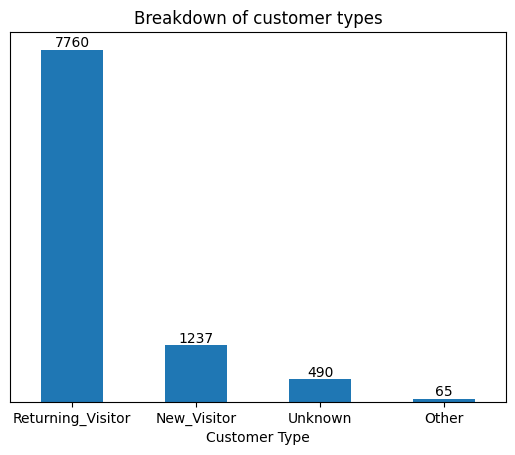

In [51]:
customer_types = df_cat['CustomerType'].value_counts()
bar_customer = customer_types.plot(kind ='bar')

bar_customer.bar_label(bar_customer.containers[0])
bar_customer.yaxis.set_visible(False)

plt.title('Breakdown of customer types')
plt.xlabel('Customer Type')
plt.xticks(rotation =0)   # angle x labels at 45 degrees
#plt.ylabel("Count")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

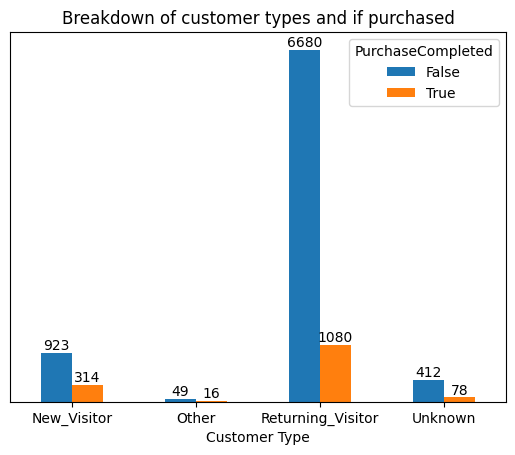

In [95]:
crosstab_customer = pd.crosstab(index=df_cat['CustomerType'], columns=df_cat['PurchaseCompleted'])
cross_cus_plot = crosstab_customer.plot(kind= 'bar')

for c in cross_cus_plot.containers:
    cross_cus_plot.bar_label(c)

cross_cus_plot.yaxis.set_visible(False)

plt.title('Breakdown of customer types and if purchased')
plt.xlabel('Customer Type')
plt.xticks(rotation =0) 
plt.show

In [100]:
# calculate ratios of customers who made a purchase 

# function to calculate ratios using numbers shown in the bar charts
def ratios(true_num, false_num):
    total = true_num + false_num
    ratio = (true_num/total)*100
    return ratio

crosstab_customer['Purchase_Ratio'] = crosstab_customer.apply(
    lambda row: ratios(row['True'], row['False']), axis=1
    )

print("Ratio of purchase by customer type:")
print(crosstab_customer['Purchase_Ratio'].round(2))

Ratio of purchase by customer type:
CustomerType
New_Visitor          25.38
Other                24.62
Returning_Visitor    13.92
Unknown              15.92
Name: Purchase_Ratio, dtype: float64


Bar chart for special day proximity

<function matplotlib.pyplot.show(close=None, block=None)>

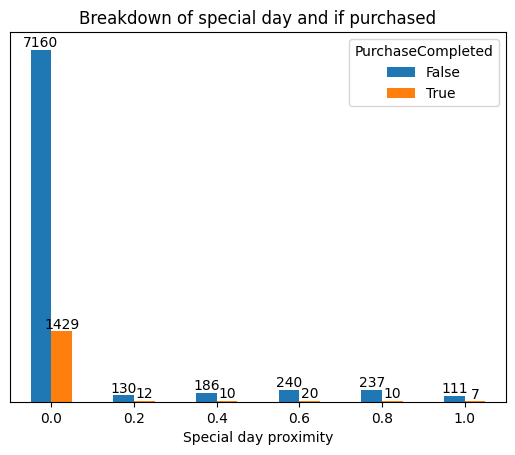

In [76]:
crosstab_day = pd.crosstab(index=df_cat['SpecialDayProximity'], columns=df_cat['PurchaseCompleted'])
cross_day_plot = crosstab_day.plot(kind= 'bar')

for d in cross_day_plot.containers:
    cross_day_plot.bar_label(d)

cross_day_plot.yaxis.set_visible(False)

plt.title('Breakdown of special day and if purchased')
plt.xlabel('Special day proximity')
plt.xticks(rotation =0) 
plt.show

In [102]:
# calculate ratios for purchases according to proximity to a special day 
crosstab_day['Purchase_Ratio'] = crosstab_day.apply(
    lambda row: ratios(row['True'], row['False']), axis=1
    )

print("Ratio of purchase by proximity to a special day:")
print(crosstab_day['Purchase_Ratio'].round(2))

Ratio of purchase by proximity to a special day:
SpecialDayProximity
0.0    16.64
0.2     8.45
0.4     5.10
0.6     7.69
0.8     4.05
1.0     5.93
Name: Purchase_Ratio, dtype: float64


Bar chart for geographic region 

<function matplotlib.pyplot.show(close=None, block=None)>

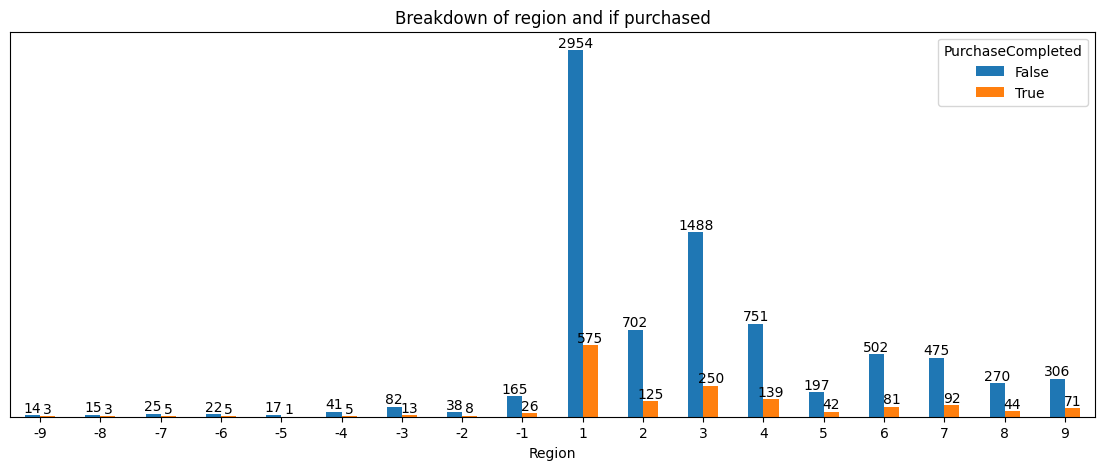

In [75]:
crosstab_geo = pd.crosstab(index=df_cat['GeographicRegion'], columns=df_cat['PurchaseCompleted'])
cross_geo_plot = crosstab_geo.plot(kind= 'bar', figsize=(14,5)) # make the chart output wider since this one has many x variables

for g in cross_geo_plot.containers:
    cross_geo_plot.bar_label(g)

cross_geo_plot.yaxis.set_visible(False)

plt.title('Breakdown of region and if purchased')
plt.xlabel('Region')
plt.xticks(rotation =0)
plt.show

In [ ]:
# calculate ratios for purchases according to region 
crosstab_geo['Purchase_Ratio'] = crosstab_geo.apply(
    lambda row: ratios(row['True'], row['False']), axis=1
    )

print("Ratio of purchase by proximity to a special day:")
print(crosstab_geo['Purchase_Ratio'].round(2))

Ratio of purchase by proximity to a special day:
GeographicRegion
-9    17.65
-8    16.67
-7    16.67
-6    18.52
-5     5.56
-4    10.87
-3    13.68
-2    17.39
-1    13.61
 1    16.29
 2    15.11
 3    14.38
 4    15.62
 5    17.57
 6    13.89
 7    16.23
 8    14.01
 9    18.83
Name: Purchase_Ratio, dtype: float64


Bar chart for traffic source

<function matplotlib.pyplot.show(close=None, block=None)>

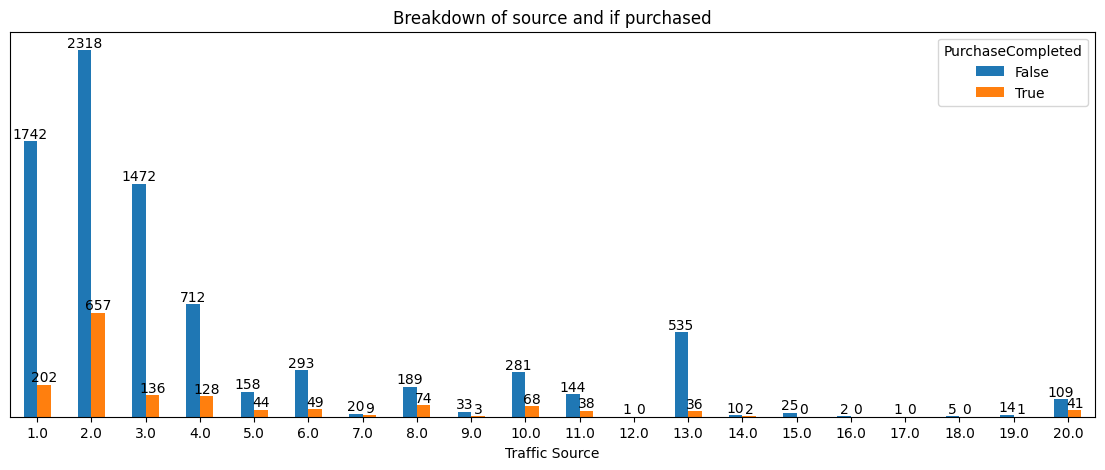

In [ ]:
crosstab_source = pd.crosstab(index=df_cat['TrafficSource'], columns=df_cat['PurchaseCompleted'])
cross_source_plot = crosstab_source.plot(kind= 'bar', figsize=(14,5)) # make the chart output wider since there's many x variables

for s in cross_source_plot.containers:
    cross_source_plot.bar_label(s)

cross_source_plot.yaxis.set_visible(False)

plt.title('Breakdown of source and if purchased')
plt.xlabel('Traffic Source')
plt.xticks(rotation =0)  
plt.show

In [104]:
# calculate ratios for purchases according to source 
crosstab_source['Purchase_Ratio'] = crosstab_source.apply(
    lambda row: ratios(row['True'], row['False']), axis=1
    )

print("Ratio of purchase by proximity to a special day:")
print(crosstab_source['Purchase_Ratio'].round(2))

Ratio of purchase by proximity to a special day:
TrafficSource
1.0     10.39
2.0     22.08
3.0      8.46
4.0     15.24
5.0     21.78
6.0     14.33
7.0     31.03
8.0     28.14
9.0      8.33
10.0    19.48
11.0    20.88
12.0     0.00
13.0     6.30
14.0    16.67
15.0     0.00
16.0     0.00
17.0     0.00
18.0     0.00
19.0     6.67
20.0    27.33
Name: Purchase_Ratio, dtype: float64


## Analysis of numerical data

In [ ]:
# create a dataframe for numerical data
df_num = df_clean[['ProductPageTime', 'BounceRate', 'ExitRate', 'PageValue']]   

print("\nSummary of numerical data")
print(df_num.describe())


Summary of numerical data
       ProductPageTime   BounceRate     ExitRate    PageValue
count      9552.000000  9552.000000  9552.000000  9552.000000
mean       1195.276432     0.019808     0.042821     5.976380
std        1945.736439     0.049128     0.048417    18.947997
min         -35.000000    -0.200000     0.000000     0.000000
25%         184.775000     0.000000     0.014035     0.000000
50%         607.483333     0.001869     0.025014     0.000000
75%        1464.834616     0.015385     0.050000     0.000000
max       63973.522230     0.200000     0.200000   361.763742
